In [1]:
# 1. Standard library imports
import logging
import math
import os
import time
from typing import Dict, List, Optional, Tuple

# 2. Related third-party imports
import numpy as np
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.amp import GradScaler, autocast
from torch.utils.checkpoint import checkpoint
from tqdm import tqdm
import tiktoken


device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [2]:
from datetime import datetime
def showTime():
    return str("["+datetime.now().strftime('%Y-%m-%d %H:%M:%S.%f')+" UTC]")

In [3]:
from pynvml import nvmlInit, nvmlDeviceGetHandleByIndex, nvmlDeviceGetMemoryInfo
def show_vram_usage():
    nvmlInit()
    handle = nvmlDeviceGetHandleByIndex(0)
    info = nvmlDeviceGetMemoryInfo(handle)
    return str(f"Used: {info.used // (1024 ** 2)} MB, Free: {info.free // (1024 ** 2)} MB, Total: {info.total // (1024 ** 2)} MB")

In [4]:
print(show_vram_usage())

Used: 747 MB, Free: 11540 MB, Total: 12288 MB


In [5]:

class MultiHeadAttention(nn.Module):
    """
    Multi-head self-attention module with causal masking for Transformer models.

    This implementation performs parallel self-attention across multiple heads using:
    1. A fused QKV projection for computational efficiency
    2. Multi-head decomposition for parallel attention computation
    3. Causal masking to prevent future context leakage in autoregressive models
    4. Final projection with residual connection and dropout

    The module follows the standard Transformer attention mechanism but with:
    - Fused QKV projection (single linear layer)
    - Causal masking for language modeling
    - Parallel attention heads with head sharing

    Args:
        n_embd (int): Total embedding dimension of input features
        num_heads (int): Number of attention heads to use
        block_size (int): Maximum sequence length for causal masking
        dropout (float): Dropout rate for attention weights and output projection
        qkv_bias (bool): Whether to include biases for Q, K, and V projections

    Attributes:
        num_heads (int): Number of attention heads
        head_size (int): Dimension of each attention head (n_embd // num_heads)
        qkv_proj (nn.Linear): Fused QKV projection layer (output dimension: 3 * n_embd)
        out_proj (nn.Linear): Final projection layer (output dimension: n_embd)
        attn_dropout (nn.Dropout): Dropout layer for attention weights
        resid_dropout (nn.Dropout): Dropout layer for final output projection
        tril (torch.Tensor): Causal mask buffer (block_size x block_size)
    """

    def __init__(self, n_embd: int, num_heads: int, block_size: int, dropout: float, qkv_bias: bool) -> None:
        """
        Initialize multi-head attention module with fused QKV projection.

        Args:
            n_embd (int): Dimension size of input embeddings
            num_heads (int): Number of parallel attention heads
            block_size (int): Maximum sequence length for causal masking
            dropout (float): Dropout probability for regularization
            qkv_bias (bool): Whether to include biases for Q, K, and V projections  
            
        Raises:
            AssertionError: If n_embd is not divisible by num_heads
            
        Notes:
            - Uses fused QKV projection (3*n_embd) instead of separate projections
            - head_size is automatically computed as n_embd // num_heads
            - Causal mask is registered as buffer for efficient sequence length slicing
        """
        super().__init__()

        # Validate head count compatibility
        assert n_embd % num_heads == 0, "Input embedding dimension must be divisible by number of heads"

         # Store configuration
        self.num_heads = num_heads
        self.head_size = n_embd // num_heads  # Automatically compute head size
        self.dropout = dropout

        # Fused QKV Projection
        # Projects input embeddings to concatenated [Q; K; V] vectors of size 3*n_embd
        # This is more efficient than separate projections due to better memory locality
        self.qkv_proj = nn.Linear(n_embd, 3 * n_embd, bias=qkv_bias)

        # Final Output Projection
        # Projects concatenated multi-head outputs back to original embedding dimension
        self.out_proj = nn.Linear(n_embd, n_embd, bias=False) # No bias in output projection

        # Regularization Layers
        # Attention dropout: applied to softmax probabilities
        self.attn_dropout = nn.Dropout(dropout)
        # Residual dropout: applied after final projection
        self.resid_dropout = nn.Dropout(dropout)

        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Compute multi-head attention output for input tensor.

        Args:
            x (Tensor): Input tensor of shape (batch_size, seq_length, n_embd)
                - batch_size (B): Number of sequences in batch
                - seq_length (T): Length of each sequence
                - n_embd (C): Embedding dimension

        Returns:
            Tensor: Output tensor of same shape (B, T, C) after attention and projection
        """
        # Get input dimensions
        B, T, C = x.size()

        # 1. Fused QKV Projection
        # Input: (B, T, C) -> Output: (B, T, 3*C)
        # Projects to concatenated [Q; K; V] vectors
        qkv = self.qkv_proj(x)

        # 2. Split into Query, Key, Value
        # Each projection is (B, T, C) where C = n_embd
        q, k, v = qkv.chunk(3, dim=2)

        # 3. Reshape for Multi-Head Attention
        # (B, T, C) -> (B, heads, T, head_size)
        # 1. View: (B, T, C) -> (B, T, heads, head_size)
        # 2. Transpose: (B, T, heads, head_size) -> (B, heads, T, head_size)
        q = q.view(B, T, self.num_heads, self.head_size).transpose(1, 2)
        k = k.view(B, T, self.num_heads, self.head_size).transpose(1, 2)
        v = v.view(B, T, self.num_heads, self.head_size).transpose(1, 2)

        # using FlashAttention for steps 4. to 8.
        out = F.scaled_dot_product_attention(
            q, k, v, 
            is_causal=True, 
            dropout_p=self.attn_dropout.p if self.training else 0.0
        )

        # 9. Concatenate Attention Heads
        # (B, heads, T, head_size) -> (B, T, heads*head_size) = (B, T, C)
        # Use contiguous() before view() to ensure memory layout compatibility
        out = out.transpose(1, 2).contiguous().view(B, T, C)

        # 10. Final Output Projection
        # (B, T, C) -> (B, T, C)
        # Apply residual dropout before returning    
        return self.resid_dropout(self.out_proj(out))


class FeedForward(nn.Module):
    """A feed-forward neural network layer with bottleneck architecture for Transformer.

    This module performs a linear transformation followed by a non-linear activation, 
    then another linear projection back to the original dimension with optional dropout.

    Args:
        n_embd (int): Input and output embedding dimension (the blocks are designed to be residual).
        dropout (float): Dropout rate for regularization. 

    Attributes:
        net (nn.Sequential): A neural network sequence comprising:
            1. A linear layer expanding to 4x input dimension.
            2. ReLU activation for non-linearity.
            3. A linear layer projecting back to original dimension.
            4. Dropout for regularization.
    """
    def __init__(self, n_embd: int, dropout: float) -> None:
        super().__init__()
        # Feeds through a ReLU-activated bottleneck layer with 4x expansion
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),      # Expand input to 4x width
            nn.GELU(),                          # Non-linear activation
            nn.Linear(4 * n_embd, n_embd),      # Back to input dimension
            nn.Dropout(dropout)                 # Regularization 
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass applying the feed-forward sequence.

        Args:
            x (Tensor): Input tensor of shape (batch_size, sequence_length, n_embd)
            
        Returns:
            Tensor: Output tensor with residual connection applied (same shape as input).
        """
        return self.net(x) # Directly applies the sequential network layers

    
class Block(nn.Module):
    """
    Transformer block combining self-attention and feed-forward layers with residual connections.

    Implements the core Transformer architecture with post-norm (normalization applied after residual connections). 

    Args:
        n_embd (int): Dimension of input embeddings.
        n_head (int): Number of self-attention heads.
        block_size (int): Maximum context length (required for causal masking).
        dropout (float): Dropout rate for attention and feed-forward layers.
        qkv_bias (bool): Whether to include biases for Q, K, and V projections

    Attributes:
        sa (MultiHeadAttention): Multi-head self-attention layer with causal masking.
        ffwd (FeedForward): Feed-forward neural network subnet.
        ln1 (nn.LayerNorm): First layer normalization to stabilize training.
        ln2 (nn.LayerNorm): Second layer normalization after feed-forward layer.
    """
    
    def __init__(self, n_embd: int, n_head: int, block_size: int, dropout: float, qkv_bias: bool, use_checkpoint: bool = True) -> None:
        super().__init__()

        self.use_checkpoint = use_checkpoint

        # Validate head count compatibility
        assert n_embd % n_head == 0, "Input embedding dimension must be divisible by number of heads"

        self.sa = MultiHeadAttention(    # Initialize causal self-attention layer
            n_embd=n_embd,
            num_heads=n_head,
            block_size=block_size,
            dropout=dropout,
            qkv_bias=qkv_bias
        )
        self.ffwd = FeedForward(n_embd=n_embd, dropout=dropout)  # Feed-forward subnet
        self.ln1 = nn.LayerNorm(n_embd, eps=1e-5)         # Normalization after attention, Match GPT-2 spec
        self.ln2 = nn.LayerNorm(n_embd, eps=1e-5)         # Normalization after feed-forward, Match GPT-2 spec
  
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Execute Transformer block computation with post-norm architecture.

        Args:
            x (Tensor): Input tensor of shape [batch_size, sequence_length, n_embd]

        Steps:
            1. Self-Attention: Compute attention with residual and LayerNorm.
            2. Feed-Forward: Apply non-linear processing with residual and LayerNorm.
            
        Returns:
            Tensor: Transformer-block processed tensor (same shape as input).
        """

        # vvvvvvvvvvvv torch.utils.checkpoint  vvvvvvvvvvvvvvvvvvvv
        if self.training and self.use_checkpoint:
            # 1. Self-Attention sublayer with checkpointing to save memory
            # Compute multi-head attention
            #sa_out = checkpoint(self.sa, x) # Post-Norm
            sa_out = checkpoint(self.sa, self.ln1(x))  # Pre-Norm before checkpointed attention
        else:
            # directly call without checkpoint in eval mode
            #sa_out = self.sa(x) # Post-Norm
            sa_out = self.sa(self.ln1(x)) # Pre-Norm
        # Add residual connection + normalize
        x = x + sa_out # Pre-Norm
        # x = self.ln1(x + sa_out) # Post-Norm

        if self.training and self.use_checkpoint:
            # 2. Feed-Forward sublayer with checkpointing
            # Non-linear bottleneck
            # ffwd_out = checkpoint(self.ffwd, x) # Post-Norm 
            ff_out = checkpoint(self.ffwd, self.ln2(x))  # Pre-Norm before checkpointed FF
        else:
            # directly call without checkpoint in eval mode
            # ffwd_out = self.ffwd(x) # Post-Norm  
            ff_out = self.ffwd(self.ln2(x))
        # Residual + normalization
        x = x + ff_out # Pre-Norm
        # x = self.ln2(x + ffwd_out) # Post-Norm  
        # ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

        return x


class GPTLanguageModel(nn.Module):
    """A full autoregressive language model with multi-head self-attention and positional embeddings.

    This model combines token and positional embeddings with a sequence of self-attention blocks to predict the next token in a sequence.

    Features:
    - Token and positional embeddings
    - Multi-head self-attention with causal masking
    - Layer normalization and residual connections
    - Weight tying between input and output embeddings
    - Advanced generation with sampling techniques

    Args:
        vocab_size: Number of tokens in vocabulary
        n_embd: Embedding dimension size
        n_head: Number of attention heads
        block_size: Maximum context length
        n_layer: Number of transformer blocks
        dropout: Dropout probability
        device: Computation device ('cpu' or 'cuda')
        qkv_bias: Enable bias for QKV projections
        ignore_index: Target value to ignore in loss calculation
    
    
    Attributes:
        vocab_size (int): Size of the token vocabulary.
        n_embd (int): Dimensionality of token and positional embeddings.
        n_head (int): Number of self-attention heads.
        block_size (int): Maximum context length the model can handle.
        n_layer (int): Number of transformer blocks in the network.
        device (str): Device for tensor operations ('cpu' or 'cuda').
        token_embedding_table (nn.Embedding): Maps tokens to embedding vectors.
        position_embedding_table (nn.Embedding): Encodes positional information up to block_size positions.
        blocks (nn.Sequential): Sequence of transformer blocks processing embeddings.
        ln_f (nn.LayerNorm): Final layer normalization after transformer blocks.
        lm_head (nn.Linear): Linear layer predicting next-token probabilities.
    """
    def __init__(
        self,
        vocab_size: int,
        n_embd: int,
        n_head: int,
        block_size: int,
        n_layer: int,
        dropout: float,
        device: str,
        qkv_bias: bool = False,       
        ignore_index: int = -100
    ) -> None:
        """Initialize the GPT-style language model.
        
        Args:
            vocab_size (int): Number of unique tokens in the vocabulary.
            n_embd (int): Dimension of token and positional embeddings (output size of embeddings).
            n_head (int): Number of parallel attention heads.
            block_size (int): Maximum sequence length the model can process.
            n_layer (int): Number of transformer blocks in the neural network.
            dropout (float): Dropout probability applied in attention and feedforward layers.
            device (str): Execution device ('cuda' for GPU acceleration).
            qkv_bias (bool): Whether to include biases for Q, K, and V projections (default: False)
            ignore_index (int): Label value to ignore in loss calculation (default: -100).
        """
        super().__init__()
        self.ignore_index = ignore_index
        self.block_size = block_size
        self.device = device
        self.n_layer = n_layer

        # Create position buffer for safe indexing
        self.register_buffer('position_ids', torch.arange(block_size))

        # 1) Embedding layers map input indices to dense vectors
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        # 2) how many indices of size n_enbd
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.drop = nn.Dropout(dropout)

        # 3) Sequential transformer blocks
        # how many decoder blocks running sequentially
        self.blocks = nn.Sequential(*[
            Block(n_embd, n_head, block_size, dropout, qkv_bias) 
            for _ in range(n_layer)
        ])

        # 4) Final processing layers
        self.ln_f = nn.LayerNorm(n_embd) # Final layer normalization stabilizes training
        # 5) Output head with/without bias
        # This projects from hidden_dim → vocab_size
        # Predict next token probabilities and always include bias
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=True) 

        # Optional
        # 6) Tie weights: Share weights between input and output embeddings
        #    Now lm_head.weight and token_embedding_table.weight are the same tensor
        #    Reduces parameters and improves convergence
        self.lm_head.weight = self.token_embedding_table.weight

        # 7) Initialize weights using standard transformer initialization strategy
        self.apply(self._init_weights)
        self.to(device) # Move all components to the specified device

    def _init_weights(self, module: nn.Module) -> None:
        """Initialize weights using heuristics from the original Transformer paper.
        
        Args:
            module (nn.Module): Module to be initialized (linear/embedding layers).
        """
        if isinstance(module, nn.Linear):
            # Weight initialization tailored for deep networks (Gaussian)
            std = 0.02 / math.sqrt(2 * self.n_layer) # Scale by depth
            torch.nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                # Bias terms initialized to zero as per best practices
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            # Embedding weights initialized with small random values
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    
    def forward(self, input_tokens: torch.Tensor, targets: Optional[torch.Tensor] = None) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        """Compute logit predictions and optionally calculate loss.
        
        Args:
            input_tokens (Tensor): Input tensor of shape (batch_size, context_length)
            targets (Tensor, optional): Target tokens of shape (batch_size, context_length)
        
        Returns:
            logits (Tensor): Unnormalized token probabilities (batch_size, context_length, vocab_size)
            loss (Tensor, optional): Loss value for training if targets provided
        """
        # Batch size and current sequence length
        B,T = input_tokens.shape

        # Validate sequence length
        if T > self.block_size:
            raise ValueError(f"Sequence length {T} exceeds block_size {self.block_size}")

        # 1. Token embeddings (B, T) → (B, T, C)
        # index and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(input_tokens) # (B,T,C)

        # 2. Positional embeddings (T) → (T, C)
        # # Positional embeddings using safe buffer indexing
        # # Avoids creating new arange tensor each forward pass
        # pos_emb = self.position_embedding_table(self.position_ids[:T])
        pos_emb = self.position_embedding_table(torch.arange(T, device=self.device))

        # 3. Combine embeddings with element-wise addition → (B, T, C) and apply dropout
        x = self.drop(tok_emb + pos_emb) # (B,T,C) with dropout

        # 4. Pass through transformer blocks → (B, T, C)
        x = self.blocks(x) # (B,T,C)

        # 5. Final layer normalization → (B, T, C)
        x = self.ln_f(x) # (B,T,C)

        # 6. Compute next-token predictions → (B, T, vocab_size)
        logits = self.lm_head(x) # (B,T,vocab_size)

        # Loss calculation (only done during training)
        loss = None
        if targets is not None:
            # Reshape to merge batch and time dimensions for cross-entropy (B*T, vocab_size)
            B,T,C = logits.shape
            logits_flat = logits.view(B*T, C)
            targets_flat  = targets.view(B*T)

            # Calculate cross-entropy loss ignoring padding tokens
            loss = F.cross_entropy(logits_flat, targets_flat , ignore_index=self.ignore_index)
            
        return logits, loss
   
    def generate(
        self, 
        input_tokens: torch.Tensor, 
        max_new_tokens: int, 
        **kwargs
    ) -> torch.Tensor:
        """Unified generation interface with sampling support.
        
        Args:
            input_tokens: (B, T) starting sequence
            max_new_tokens: Number of tokens to generate
            **kwargs: Sampling parameters passed to advanced_generation
            
        Returns:
            Generated sequence (B, T + max_new_tokens)
        """
        return self.advanced_generation(
            input_tokens, 
            max_new_tokens, 
            temperature=1.0, 
            **kwargs
        )
    
    def advanced_generation(self,
        input_tokens: torch.Tensor,
        max_new_tokens: int,
        temperature: float = 1.0,
        top_k: Optional[int] = None,
        top_p: Optional[float] = None,
        eos_token_id: int = 50256
    ) -> torch.Tensor:
        """Generate tokens with advanced sampling strategies (temperature, nucleus, top-k).
        
        Args:
            input_tokens (Tensor): Initial tokens of shape (B, T)
            max_new_tokens (int): Maximum tokens to generate
            temperature (float): Controls randomness (1=default, 0→deterministic)
            top_k (int, optional): Keep only top K most probable tokens (None→disabled)
            top_p (float, optional): Keep smallest window ≥ cumulative prob mass p (None→disabled)
        
        Returns:
            Tensor: Generated sequence (B, T + max_new_tokens)
        """

        # Validate sampling parameters
        if temperature < 0:
            raise ValueError("Temperature must be >= 0")
        if top_k is not None and top_k <= 0:
            raise ValueError("top_k must be positive integer or None")
        if top_p is not None and not (0 < top_p <= 1):
            raise ValueError("top_p must be in (0, 1] range")
        
        for _ in range(max_new_tokens):
            # Crop to block_size with efficient slicing
            cropped_input = input_tokens[:, -self.block_size:]

            # Get predictions without loss calculation
            logits, _ = self(cropped_input)

            # Only consider last predicted token
            next_logits = logits[:, -1, :] 

            # Handle greedy sampling separately for efficiency
            if temperature == 0.0:
                next_token = torch.argmax(next_logits, dim=-1, keepdim=True)
                input_tokens = torch.cat((input_tokens, next_token), dim=1)
                continue

            # Temperature scaling controls exploration-exploitation tradeoff
            scaled_logits = next_logits / temperature

            # Top-k filtering
            if top_k is not None:
                # Find top-k values (dynamic k for small vocabularies)
                k = min(top_k, scaled_logits.size(-1))
                top_k_vals = torch.topk(scaled_logits, k, dim=-1).values
                # Create mask and apply
                mask = scaled_logits < top_k_vals[:, [-1]]
                scaled_logits = scaled_logits.masked_fill(mask, -float('inf'))

            # Convert to probabilities after any pre-processing
            probs = F.softmax(scaled_logits, dim=-1)

            # Apply nucleus (top-p) sampling (if requested)
            if top_p is not None:
                # Sort probabilities in descending order
                sorted_probs, sorted_indices = torch.sort(probs, dim=-1, descending=True)
                cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

                # Determine indices to mask by identifying positions exceeding p
                sorted_indices_to_remove = cumulative_probs > top_p

                # Keep first token above threshold
                sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
                sorted_indices_to_remove[..., 0] = False

                # Create original-order mask
                remove_mask = torch.zeros_like(probs, dtype=torch.bool)
                remove_mask.scatter_(-1, sorted_indices, sorted_indices_to_remove)

                # Filter and renormalize
                probs = probs.masked_fill(remove_mask, 0.0)
                probs = probs / probs.sum(dim=-1, keepdim=True)

            # Sample with controlled probability distribution
            next_token = torch.multinomial(probs, num_samples=1)

            # Extend sequence
            input_tokens = torch.cat((input_tokens, next_token), dim=1)

            # If we generated EOS, stop immediately
            if next_token.item() == eos_token_id:
                break

        return input_tokens  # Final expanded tensor
    


In [6]:
print(show_vram_usage())

Used: 747 MB, Free: 11540 MB, Total: 12288 MB


In [7]:
# # Example usage test
# vocab_size_test = 50258
# embedding_size_test = 256
# number_of_heads_test = 4
# block_size_test = 128
# number_of_blocks_test = 1
# dropout_test = 0.2
# head_size_test = embedding_size_test // number_of_heads_test
# device_test = 'cuda' if torch.cuda.is_available() else 'cpu'


# model = GPTLanguageModel(
#     vocab_size=vocab_size_test,
#     n_embd=embedding_size_test,
#     n_head=number_of_heads_test,
#     block_size=block_size_test,
#     n_layer=number_of_blocks_test,
#     dropout=dropout_test,
#     device=device_test
# )

# model_size = sum(p.numel() for p in model.parameters() if p.requires_grad)
# print(f"Model size: {model_size / 1e6:.2f}M parameters")

# print(
#     f"Model created with {embedding_size_test=}, {number_of_heads_test=}, head_size={embedding_size_test//number_of_heads_test}")

# # Create dummy input
# input_tokens = torch.randint(0, vocab_size_test, (2, 50), device=device_test)

# # Test forward pass
# # Use input as target for testing shape
# logits, loss = model(input_tokens, targets=input_tokens)
# if loss is not None:
#     print("Loss:", loss.item())

# # Test generation
# print("Generating...")
# # Start generation from first 10 tokens
# generated_tokens = model.generate(input_tokens[:, :10], max_new_tokens=20)
# print("Generated tokens shape:", generated_tokens.shape)
# print("Generated sequence example (first batch):\n",
#         generated_tokens[0].tolist())

# # Test advanced generation
# print("\nAdvanced Generating (top_k=5, temp=0.8)...")
# generated_tokens_adv = model.advanced_generation(
#     input_tokens[:, :10],
#     max_new_tokens=20,
#     temperature=0.8,
#     top_k=10
# )
# print("Generated tokens shape (adv):", generated_tokens_adv.shape)
# print("Generated sequence example (adv, first batch):\n",
#         generated_tokens_adv[0].tolist())

In [8]:
print(show_vram_usage())

Used: 748 MB, Free: 11539 MB, Total: 12288 MB


GPT2 Training Sliding Window 50% Overlap

In [9]:
## -- Utility Functions ---------------------------------------------------
# -- Getting Size of Vocab Function ------------------------------------------
def get_vocab_size(encoding_name: str) -> int:
    """
    Return the vocabulary size for a given encoding in tiktoken.

    Args:
        encoding_name: Name of the encoding (e.g. "gpt2", "cl100k_base", etc.)

    Returns:
        The total number of tokens in that encoding’s vocabulary.
    """
    encoding = tiktoken.get_encoding(encoding_name)
    return encoding.n_vocab


# -- Batch Extraction Function ------------------------------------------
def get_batch_for_training(
    batch_idx: int,
    data: np.ndarray,
    window_starts: List[int],
    block_size: int,
    batch_size: int,
    device: torch.device
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Extract batch of sequences using vectorized operations. 
    Optimized for memory-mapped files by reading larger contiguous blocks.

    Args:
        batch_idx: Index of the batch to retrieve.
        data: NumPy array or memmap of token IDs.
        window_starts: List of start indices for sliding windows.
        block_size: Number of tokens per input sequence.
        batch_size: Number of sequences per batch.
        device: Torch device (cpu or cuda).

    Returns:
        x_batch: Tensor of shape (batch_size, block_size).
        y_batch: Tensor of shape (batch_size, block_size), one-step-shifted targets.
    """
    # Determine which window starts belong to this batch
    starts = window_starts[batch_idx * batch_size: (batch_idx + 1) * batch_size]
    # Calculate end positions for entire batch at once
    ends = [s + block_size + 1 for s in starts]
    # Find min/max to read single contiguous block
    read_start = min(starts)
    read_end = max(ends)
    # Read large contiguous block
    block = np.copy(data[read_start:read_end])# Force single read
    # Extract sequences from the block
    x_list = [block[s-read_start : s-read_start+block_size] for s in starts]
    y_list = [block[s-read_start+1 : s-read_start+block_size+1] for s in starts]
    # Gather input and target sequences
    x_np = np.stack(x_list)
    y_np = np.stack(y_list)
    # Convert to Torch tensors on the target device
    x_batch = torch.tensor(x_np, dtype=torch.long, device=device)
    y_batch = torch.tensor(y_np, dtype=torch.long, device=device)
    return x_batch, y_batch


# --- Sample a random batch for loss estimation --------------------------------
def get_batch_for_loss_estimation(
    data: np.ndarray,
    window_starts: List[int],
    block_size: int,
    batch_size: int,
    device: torch.device
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Samples random batch from precomputed window starts.
    Handles cases where sample pool is smaller than batch size.
    
    Args:
        data: Memory-mapped token array
        window_starts: Precomputed valid window positions
        block_size: Sequence length
        batch_size: Number of sequences per batch
        device: Target device (cpu/cuda)
    
    Returns:
        (x_batch, y_batch): Input-target sequence pair
    """
    
    # Handle case where window pool is smaller than batch size
    replace = len(window_starts) < batch_size 
     
    # Randomly sample window indices
    indices = np.random.choice(
        len(window_starts), 
        size=batch_size, 
        replace=replace  # Allow sampling with replacement if needed
    )
    starts = [window_starts[i] for i in indices]
    
    # Read sequences
    x_list = [data[s:s+block_size] for s in starts]
    y_list = [data[s+1:s+block_size+1] for s in starts]
    
    # Convert to tensors
    x_batch = torch.tensor(np.stack(x_list), dtype=torch.long, device=device)
    y_batch = torch.tensor(np.stack(y_list), dtype=torch.long, device=device)
    return x_batch, y_batch


# -- Estimate Loss -------------------------------------------------
@torch.no_grad()
def estimate_loss(
    model,
    data: np.ndarray,
    train_window_starts: List[int],
    val_window_starts: List[int],
    block_size: int,
    batch_size: int,
    device: str,
    eval_iters: int = 50
) -> Dict[str, float]:
    losses = {}
    model.eval()
    
    for split, window_starts in [('train', train_window_starts), ('val', val_window_starts)]:
        total = 0.0
        for _ in range(eval_iters):
            X, Y = get_batch_for_loss_estimation(
                data, window_starts, block_size, batch_size, device
            )
            with torch.autocast(device_type=device, dtype=torch.bfloat16):
                _, loss = model(X, Y)
            total += loss.item()
        losses[split] = total / eval_iters
    
    model.train()
    return losses


# -- Checkpoint Saving -------------------------------------------------
def save_checkpoint(
    model: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    loss: float,
    batches_seen: List[int],
    train_losses: List[float],
    val_losses: List[float],
    file_path: str,
    scaler: torch.cuda.amp.GradScaler = None, # Optional scaler argument
    warmup_scheduler: torch.optim.lr_scheduler.LRScheduler = None,  # Optional warmup argument
    plateau_scheduler: torch.optim.lr_scheduler.LRScheduler = None  # Optional plateau argument
) -> None:
    """ 
    Save model, optimizer, scaler (optional), and training history to disk for later resumption and plotting.

    Args:
        model (torch.nn.Module): Trained GPTLanguageModel.
        optimizer (torch.optim.Optimizer): Associated optimizer (e.g., AdamW).
        epoch (int): Current epoch or step number.
        loss (float): Latest loss value.
        batches_seen (List[int]): List of batch-indices at which evals were performed.
        train_losses (List[float]): Recorded training losses at each eval point.
        val_losses (List[float]): Recorded validation losses at each eval point.
        file_path (str): File path for checkpoint.
        scaler (torch.cuda.amp.GradScaler, optional): GradScaler for mixed precision training.

    Notes:
        - Saves a dict with keys:
          * 'epoch', 'model_state_dict', 'optimizer_state_dict', 'loss'
          * 'history': contains 'batches_seen', 'train_losses', 'val_losses'
          * 'scaler_state_dict' (if scaler is provided)
        - Later, loading this checkpoint allows both exact model/optimizer restoration
          and re-plotting of the entire train/val loss curve.
    """
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
        'history': {
            'batches_seen': batches_seen,
            'train_losses': train_losses,
            'val_losses': val_losses,
        }
    }
    if scaler is not None:
        checkpoint['scaler_state_dict'] = scaler.state_dict()
    if warmup_scheduler is not None:
        checkpoint['warmup_state_dict'] = warmup_scheduler.state_dict()
    if plateau_scheduler is not None:
        checkpoint['plateau_scheduler_state_dict'] = plateau_scheduler.state_dict()
    torch.save(checkpoint, file_path)


def get_total_params_gpt2(model: torch.nn.Module) -> int:
    """
    Compute the total number of *unique* trainable parameters in a GPT-2 model,
    correctly accounting for weight tying between the input embeddings and the
    output language modeling head.

    GPT-2 ties the weights of its input embedding matrix and the output projection
    (lm_head).  Although these weights appear twice in the model's parameter list,
    they should only be counted once when reporting the total number of parameters.

    Args:
        model (torch.nn.Module):
            A GPT-2 model instance (e.g. from Hugging Face's transformers library),
            which must have an attribute `lm_head` representing the output projection
            layer.

    Returns:
        int: The total number of unique parameters in the GPT-2 model, with the
             duplicated `lm_head` parameters subtracted out.
    """
    # 1) Count every parameter in the model (embeddings, transformer blocks, lm_head, etc.)
    total_params = sum(p.numel() for p in model.parameters())

    # 2) Count only the parameters in the output head (lm_head).
    #    These share weights with the input embedding matrix under weight-tying.
    lm_head_params = sum(p.numel() for p in model.lm_head.parameters())

    # 3) Subtract the lm_head params once so they're not double-counted,
    #    yielding the true GPT-2 parameter count.
    unique_gpt2_params = total_params - lm_head_params

    return unique_gpt2_params

def get_total_model_size_mb(model: torch.nn.Module) -> int:
    total_params = sum(p.numel() for p in model.parameters())
    total_size_bytes = total_params * 4 #A
    total_size_mb = total_size_bytes / (1024 * 1024) #B
    return total_size_mb

In [10]:
# -- Logging Configuration ----------------------------------------------
run_id = int(time.time())

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S", 
    encoding='utf-8'
)
logger = logging.getLogger(__name__)

# Ensure logs directory exists
LOG_DIR = os.path.join("logs")
if not os.path.exists(LOG_DIR):
    os.makedirs(LOG_DIR)

# Create file handler
log_file = os.path.join(LOG_DIR, f"train_{run_id}.log")
file_handler = logging.FileHandler(log_file, mode='w', encoding='utf-8')
file_handler.setLevel(logging.DEBUG)

# Optional: use same format as console
formatter = logging.Formatter("%(asctime)s [%(levelname)s] %(message)s", "%H:%M:%S")
file_handler.setFormatter(formatter)

# Add handler to logger
logger.addHandler(file_handler)
logger.info(f"Logging to file: {log_file}")

# -- Load Tokenizer -----------------------------------------------------
encoding_name = "gpt2"
tokenizer = tiktoken.get_encoding(encoding_name)
vocab_size = get_vocab_size(encoding_name) 
while(vocab_size%64 != 0): vocab_size+=1 # override with larger value that is divisable by 64 
logger.info(f"Vocab size: {vocab_size}")

# -- Model Configuration ------------------------------------------------
torch.manual_seed(1337)
block_size = 1024
n_embd = 1024 # 768 1024 1280
n_head = 16 # 12 16 20
n_layer = 24 # 12 24 36
dropout = 0.1
batch_size = 4

device = 'cuda' if torch.cuda.is_available() else 'cpu'
logger.info(f"Using device: {device}")

# create an instance of GPTLanguageModel class
model = GPTLanguageModel(
    vocab_size=vocab_size, 
    block_size=block_size,
    n_embd=n_embd,
    n_head=n_head,
    n_layer=n_layer,
    dropout=dropout,
    device=device
).to(device)
#logger.info(f"Model parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")
logger.info(f"Model parameters: {get_total_params_gpt2(model)/1e6:.2f}M")
logger.info(f"Total size of the model: {get_total_model_size_mb(model):.2f} MB")

# -- Load Data ----------------------------------------------------------
# Load as a memory mapped file object by using mmap_mode='r' to save RAM
data = np.load(
    os.path.join('output_v10', 'encoded_data','encoded_output_v10_accuracy.npy'),
    mmap_mode='r'
)
logger.info(f"Data shape: {data.shape}")

# -- Train/Val Split -----------------------------------------------------
# allocating 90% for training and 10% for validation
split_index = int(0.9 * len(data))

# -- Prepare Overlapping Windows -----------------------------------
# Desired fraction of overlap between successive windows
overlap_frac = 0.0625   
#overlap_frac = 0.5   
# Compute the stride (how far the window moves each time)
stride = int(block_size * (1 - overlap_frac))  

# Precompute training and validation windows
# Training windows: [0, split_index - block_size - 2]
# -2 ensures room for x (block_size) and y (block_size+1)
max_train_start = split_index - block_size - 2
train_window_starts = list(range(0, max_train_start + 1, stride))

# Validation windows: [split_index, len(data) - block_size - 2]
# Isolated from training data with safety buffer
max_val_start = len(data) - block_size - 2
val_window_starts = list(range(split_index, max_val_start + 1, stride))

# Create mutable copy for training 
window_starts = train_window_starts.copy()  # Will be shuffled each epoch
num_windows = len(window_starts)
total_batches = num_windows // batch_size
logger.info(f"Train windows: {len(train_window_starts)}, Val windows: {len(val_window_starts)}")
logger.info(f"Total overlapping windows: {num_windows}, total_batches: {total_batches}")

# -- Optimizer & Training Setup -----------------------------------------
grads_accum_steps = 2
initial_eval_interval = 32
max_eval_interval = 1000
eval_interval = initial_eval_interval
num_epochs = 20  # configurable number of epochs
val_loss_threshold = 2.0  # stop if val loss exceeds threshold x train loss
warmup_steps = 2000

best_val_loss = float('inf')
patience_counter = 0
patience_limit = 3 # stop if no improvement in val loss after patience_limit checks

learning_rate = 1e-4
optimizer = torch.optim.AdamW(
    model.parameters(), 
    lr=learning_rate,
    weight_decay=0.01  # Regularization
)
warmup = torch.optim.lr_scheduler.LambdaLR(
    optimizer, 
    lr_lambda=lambda step: min(1.0, (step * grads_accum_steps) / warmup_steps)  # 1000-step warmup
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,   # new_LR = LR*factor
    patience=1,   # number of evals with no improvement to wait before appying new_LR
    min_lr = 1e-6
)

# generate from the model before training
input_tokens = tokenizer.encode("I like apple juice, I drink it")
input_tokens = torch.tensor(input_tokens, dtype=torch.long).unsqueeze(0).to(device)
model.eval()
with torch.no_grad():
    output = model.generate(input_tokens=input_tokens, max_new_tokens=30)
# Safe decoding: ignore tokens outside tokenizer's known range
decoded = tokenizer.decode([t for t in output[0].tolist() if t < tokenizer.n_vocab])
logger.info(f"Model output: \n{decoded}")
model.train()


14:00:20 [INFO] Logging to file: logs\train_1749384020.log


In [11]:
print(show_vram_usage())



Used: 2245 MB, Free: 10042 MB, Total: 12288 MB


In [ ]:

# -- Start of training run ------------------------------------------------------
pre_training_dir = os.path.join('output_v11', 'pre_training', f'run_{run_id}')
if not os.path.exists(pre_training_dir):
    os.makedirs(pre_training_dir)
    logger.info(f"Created: {pre_training_dir}")

class DummyScaler:  # For CPU compatibility
    def scale(self, loss): return loss
    def step(self, optimizer): optimizer.step()
    def update(self): pass
    def state_dict(self): return {}
    def load_state_dict(self, _): pass

# -- Tracking metrics ------------------------------------------------------
batches_processed = 0
last_grad_norm = 0.0
train_losses, val_losses, batches_seen = [], [], []
val_loss = None
early_stop = False
t0 = time.time()
# Initialize and autoselect GradScaler for mixed precision
scaler = GradScaler() if device == 'cuda' else DummyScaler()

# -- Training Loop ------------------------------------------------------
torch.set_float32_matmul_precision('high')

for epoch in range(num_epochs):
    if early_stop == True:
        break
    # Shuffle before each epoch, to prevent ordered exposure and reduced learning effectiveness
    np.random.shuffle(window_starts) 
    logger.info(f"Starting epoch {epoch + 1}/{num_epochs}")
    optimizer.zero_grad(set_to_none=True)
    # Reset epoch timer
    t0_epoch = time.time()
    t0 = time.time()

    for batch_idx in tqdm(range(total_batches), desc='Training'):
        X, Y = get_batch_for_training(batch_idx, data, window_starts, block_size, batch_size, device)
        with torch.autocast(device_type=device, dtype=torch.bfloat16):
            _, loss = model(X, Y)
            loss = loss / grads_accum_steps
            
        if torch.isnan(loss).any():
            logger.error("NaN loss at batch %d", batches_processed)
            early_stop = True
            break  # Exit batch loop

        # Backward pass with GradScaler
        scaler.scale(loss).backward()
        batches_processed += 1

        if (batches_processed) % grads_accum_steps == 0:
            scaler.unscale_(optimizer)
            last_grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(), 
                max_norm=1.0
            )    # preventing exploding gradients
            # Optimizer step with GradScaler
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            if batches_processed < warmup_steps:  # Warmup steps completed
                warmup.step() 
                current_lr = optimizer.param_groups[0]['lr']
                logger.debug(f"Warmup step {batches_processed}/{warmup_steps} - LR: {current_lr:.2e}")

        if (batches_processed) % eval_interval == 0:
            metrics = estimate_loss(
                model, data, 
                train_window_starts,  # Use precomputed training windows
                val_window_starts,    # Use precomputed validation windows
                block_size, batch_size, device,
                eval_iters=max(50, eval_interval//16)
            )
            
            # timing and logging
            dt = time.time() - t0; t0 = time.time()
            train_loss, val_loss = metrics['train'], metrics['val']
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            batches_seen.append(batches_processed)
            
            current_lr = optimizer.param_groups[0]['lr']
            # combined logging (loss + LR)
            logger.info(
                f"[Epoch {epoch+1}/{num_epochs}] Batch {batches_processed}: "
                f"train={train_loss:<7.4f} | val={val_loss:<7.4f} | "
                f"lr={current_lr:.8f} | grad_norm={last_grad_norm:<7.4f} | time={dt:.3f}s"
            )

            # double the eval_interval (but never exceed max_eval_interval)
            eval_interval = min(eval_interval * 2, max_eval_interval)

    # # Final partial update at epoch end
    if batches_processed % grads_accum_steps != 0 and not early_stop:
        scaler.unscale_(optimizer)
        last_grad_norm = torch.nn.utils.clip_grad_norm_(
            model.parameters(), 
            max_norm=1.0
        )
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        # Add after warmup period
        if batches_processed < warmup_steps:  # Warmup steps completed
            warmup.step() 
            current_lr = optimizer.param_groups[0]['lr']
            logger.info(f"Warmup step {batches_processed}/{warmup_steps} - LR: {current_lr:.2e}")

    # Epoch-end evaluation
    if not early_stop:
        metrics = estimate_loss(
            model, data, train_window_starts, val_window_starts,
            block_size, batch_size, device,
            eval_iters=eval_interval//2  # More thorough evaluation
        )
        train_loss, val_loss = metrics['train'], metrics['val']
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        batches_seen.append(batches_processed)
        
        # ONLY step scheduler when new validation exists (if past warmup and validation available)
        if val_loss is not None and batches_processed >= warmup_steps:
            scheduler.step(val_loss)
            
        current_lr = optimizer.param_groups[0]['lr']
        epoch_time = time.time() - t0_epoch
        
        logger.info(
            f"End of Epoch {epoch+1}/{num_epochs} | "
            f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
            f"lr={current_lr:.6f} | time={epoch_time:.2f}s"
        )

    # Divergence guard: stop if val loss too high
    if val_loss > val_loss_threshold * train_loss:
        logger.warning(f"Validation loss {val_loss:.4f} exceeds {val_loss_threshold}x training loss {train_loss:.4f}. Stopping early.")
        save_checkpoint(
            model=model,
            optimizer=optimizer,
            epoch=batches_processed,
            loss=loss.item(),
            batches_seen=batches_seen,
            train_losses=train_losses,
            val_losses=val_losses,
            file_path=os.path.join(pre_training_dir, f"checkpoint_earlystop_{batches_processed}_epoch_{epoch+1}.pth"),
            scaler=scaler,  # Save scaler state (optional)
            warmup_scheduler=warmup,
            plateau_scheduler=scheduler
        )
        early_stop = True
        break

    # Early stopping logic: stop if no improvement in val loss for patience_limit number of checks
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
    else:
        patience_counter += 1
        logger.info(f"No val_loss improvement for {patience_counter}/{patience_limit} evals.")
        if patience_counter >= patience_limit:
            logger.warning(f"Early stopping: validation loss has not improved for {patience_limit} evals.") 
            save_checkpoint(
                model=model,
                optimizer=optimizer,
                epoch=batches_processed,
                loss=loss.item(),
                batches_seen=batches_seen,
                train_losses=train_losses,
                val_losses=val_losses,
                file_path=os.path.join(pre_training_dir, f"checkpoint_earlystop_{batches_processed}_epoch_{epoch+1}.pth"),
                scaler=scaler,  # Save scaler state (optional)
                warmup_scheduler=warmup,
                plateau_scheduler=scheduler
            )  
            early_stop = True
            break
                    
    # save checkpoint at end of epoch
    save_checkpoint(
        model=model,
        optimizer=optimizer,
        epoch=batches_processed,
        loss=loss.item(),
        batches_seen=batches_seen,
        train_losses=train_losses,
        val_losses=val_losses,
        file_path=os.path.join(pre_training_dir, f"checkpoint_epoch_{epoch+1}.pth"),
        scaler=scaler,  # Save scaler state (optional)
        warmup_scheduler=warmup,
        plateau_scheduler=scheduler
    )

    # generate from the model at end of epoch
    input_tokens = tokenizer.encode("I like apple juice, I drink it")
    input_tokens = torch.tensor(input_tokens, dtype=torch.long).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        output = model.generate(input_tokens=input_tokens, max_new_tokens=30)
    # Safe decoding: ignore tokens outside tokenizer's known range
    decoded = tokenizer.decode([t for t in output[0].tolist() if t < tokenizer.n_vocab])
    logger.info(f"Model output: \n{decoded}")
    model.train()

if early_stop:
    logger.info("Training stopped early by early stopping criteria.")
else:
    logger.info("Training completed all epochs/batches.")

13:56:02 [INFO] Created: output_v11\pre_training\run_1749383757
13:56:02 [INFO] Starting epoch 1/20
Training:   0%|          | 0/5443 [00:00<?, ?it/s]f:\OneDrive\github\LLM_from_scratch\cuda\lib\site-packages\torch\_dynamo\eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
Training:   3%|▎         | 189/5443 [03:36<1:06:23,  1.32it/s]

13:33:11 [INFO] Generating plot: training and validation loss vs batch number.


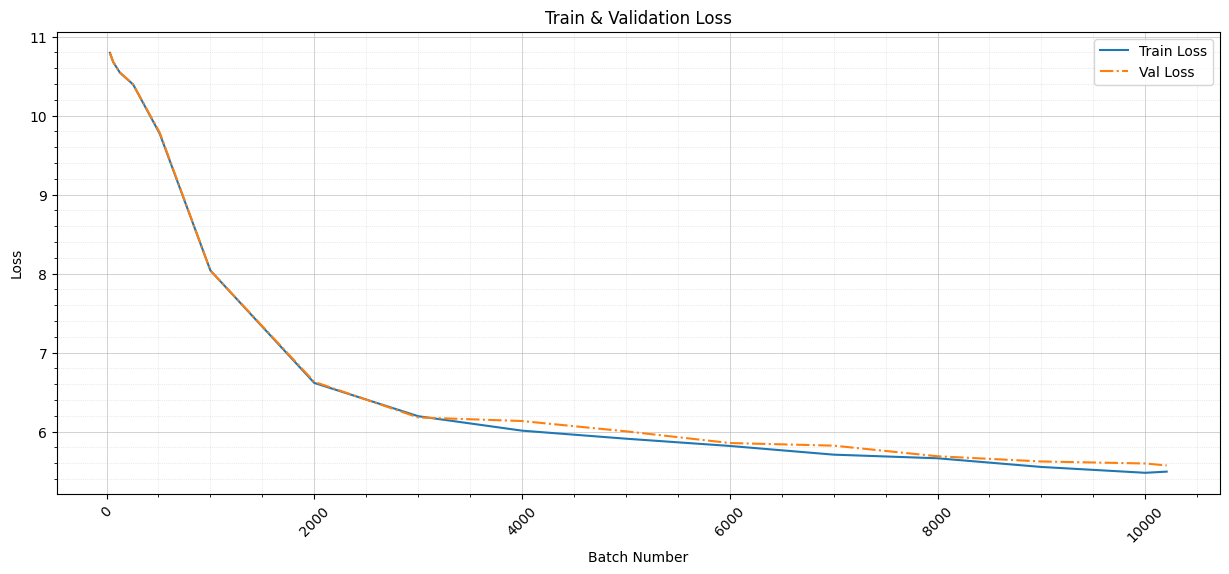

In [13]:
# -- Plot training and validation loss vs batch number ------------------------------------------------------
import matplotlib.pyplot as plt

def plot_train_val_loss(batches_seen, train_losses, val_losses):
    logger.info("Generating plot: training and validation loss vs batch number.")

    fig, ax1 = plt.subplots(figsize=(15,6))

    # Plot training and validation loss against epochs
    ax1.plot(batches_seen, train_losses, label="Train Loss")
    ax1.plot(batches_seen, val_losses, linestyle="-.", label="Val Loss")
    ax1.set_xlabel("Batch Number")
    #ax1.set_ylim(0)
    ax1.set_ylabel("Loss")
    ax1.set_title("Train & Validation Loss")
    ax1.legend(loc="upper right")
    # --- Add Subgrid (Minor Grid Lines) ---
    ax1.minorticks_on()  # Enable minor ticks
    # Major grid (main grid lines)
    ax1.grid(True, which='major', linestyle='-', linewidth=0.5, alpha=0.8)
    # Minor grid (subgrid lines)
    ax1.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.5)
    ax1.grid(True)

    #fig.tight_layout()  # Adjust layout to make room
    plt.xticks(rotation=45)
    plt.savefig(f"loss-plot-{run_id}.pdf")
    plt.show()

plot_train_val_loss(batches_seen, train_losses, val_losses)


In [ ]:
# generate from the model
input_tokens = tokenizer.encode("I like apple juice - I drink it")
input_tokens = torch.tensor(input_tokens, dtype=torch.long).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model.advanced_generation(input_tokens=input_tokens, max_new_tokens=40, temperature=1.3, top_k=20)

# Safe decoding: ignore tokens outside tokenizer's known range
decoded = tokenizer.decode([t for t in output[0].tolist() if t < tokenizer.n_vocab])
logger.info(f"Model output: \n{decoded}")

In [ ]:
from pynvml import nvmlInit, nvmlDeviceGetHandleByIndex, nvmlDeviceGetMemoryInfo

nvmlInit()
handle = nvmlDeviceGetHandleByIndex(0)
info = nvmlDeviceGetMemoryInfo(handle)

print(f"Used: {info.used // (1024 ** 2)} MB, Free: {info.free // (1024 ** 2)} MB, Total: {info.total // (1024 ** 2)} MB")

In [12]:
# # Unload existing model to free up memory
# def cleanup_gpu():
#     try:
#         import gc, torch
#         del model
#         del optimizer
#         del scaler
#         # Delete all variables/tensors you used
#         for name in dir():
#             obj = globals().get(name)
#             if torch.is_tensor(obj) or (hasattr(obj, 'to') and callable(obj.to)):
#                 del obj
#         gc.collect()
#         torch.cuda.empty_cache()
#         torch.cuda.ipc_collect()
#         print("GPU memory cleanup complete.")
#     except NameError:
#         print("No previous model to unload.")


In [ ]:
# cleanup_gpu()

In [ ]:
# # -- load model form checkpoint----------------------------------------------------

# # 1) Re‑instantiate everything with the *same* hyperparameters
# vocab_size = 50304
# block_size = 1024
# n_embd = 1024 # 768 1024 1280
# n_head = 16 # 12 16 20
# n_layer = 24 # 12 24 36
# dropout = 0.1
# device = 'cuda' if torch.cuda.is_available() else 'cpu'

# model = GPTLanguageModel(
#     vocab_size=vocab_size,
#     block_size=block_size,
#     n_embd=n_embd,
#     n_head=n_head,
#     n_layer=n_layer,
#     dropout=dropout,
#     device=device
# ).to(device)

# optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
# scaler = GradScaler(device, enabled=(device == 'cuda'))

# # 2) Load tokenizer as before
# encoding_name = "gpt2"
# tokenizer = tiktoken.get_encoding(encoding_name)

# # 3) Point to your checkpoint
# ckpt_path = r"output_v11\pre_training\run_1748832148\checkpoint_earlystop_65000_epoch_4.pth"
# assert os.path.isfile(ckpt_path), f"Checkpoint not found at {ckpt_path}"

# # 4) Load the checkpoint
# ckpt = torch.load(ckpt_path, map_location=device)
# model.load_state_dict(ckpt['model_state_dict'])
# optimizer.load_state_dict(ckpt['optimizer_state_dict'])

# # If you saved the scaler state dict, restore it
# if 'scaler_state_dict' in ckpt:
#     scaler.load_state_dict(ckpt['scaler_state_dict'])

# # When loading checkpoint:
# if 'warmup_scheduler_state_dict' in checkpoint:
#     warmup_scheduler.load_state_dict(checkpoint['warmup_scheduler_state_dict'])
# if 'plateau_scheduler_state_dict' in checkpoint:
#     scheduler.load_state_dict(checkpoint['plateau_scheduler_state_dict'])

# # Load plot history
# history = ckpt['history']
# batches_seen = history['batches_seen']
# train_losses = history['train_losses']
# val_losses   = history['val_losses']

# start_step = ckpt.get('epoch', None)
# print(f"Loaded checkpoint from step {start_step}. Resuming from there.")

# # 5) (Optional) Set model to eval or train
# # For continued training:
# model.train()
# # For inference only:
# # model.eval()

# # 6) Example inference to verify it works:
# # generate from the model
# input_tokens = tokenizer.encode("I like apple juice - I drink it")
# input_tokens = torch.tensor(input_tokens, dtype=torch.long).unsqueeze(0).to(device)

# model.eval()
# with torch.no_grad():
#     output = model.advanced_generation(input_tokens=input_tokens, max_new_tokens=50, temperature=1.7, top_k=10)

# # Safe decoding: ignore tokens outside tokenizer's known range
# decoded = tokenizer.decode([t for t in output[0].tolist() if t < tokenizer.n_vocab])
# logger.info(f"Model output: \n{decoded}")